# ⭐ Day 56: LightGBM
## Faster and More Efficient Gradient Boosting

**Day 56 of 369-day Python & AI Learning Path** 🚀

---

Welcome to Day 56! Today we explore **LightGBM** (Light Gradient Boosting Machine) — Microsoft's revolutionary gradient boosting framework that has taken the machine learning world by storm with its exceptional speed and efficiency.

## 📋 Table of Contents

1. [Introduction to LightGBM and Why It Is So Fast](#1-introduction-to-lightgbm-and-why-it-is-so-fast)
2. [Key Innovations in LightGBM](#2-key-innovations-in-lightgbm)
3. [Installing and Using LightGBM](#3-installing-and-using-lightgbm)
4. [LightGBM Classifier and Regressor](#4-lightgbm-classifier-and-regressor)
5. [Important Hyperparameters Deep Dive](#5-important-hyperparameters-deep-dive)
6. [Applying LightGBM to Titanic Dataset](#6-applying-lightgbm-to-titanic-dataset)
7. [Training with Early Stopping and Validation Set](#7-training-with-early-stopping-and-validation-set)
8. [Feature Importance in LightGBM](#8-feature-importance-in-lightgbm)
9. [Comparison: XGBoost vs LightGBM](#9-comparison-xgboost-vs-lightgbm)
10. [Best Practices and Tips for Using LightGBM](#10-best-practices-and-tips-for-using-lightgbm)
11. [Hands-On Exercises](#-hands-on-exercises)
12. [Solutions](#solutions-review-after-attempting)


## 1. Introduction to LightGBM and Why It Is So Fast

LightGBM is a gradient boosting framework developed by Microsoft that uses tree-based learning algorithms. It is designed to be **distributed and efficient** with the following advantages:

### ⚡ Why LightGBM Is So Fast:

**1. Novel Splitting Strategies:**
- Uses histogram-based algorithms instead of pre-sorted algorithms
- Reduces complexity from O(#data × #features) to O(#bins × #features)

**2. Leaf-wise Tree Growth:**
- Grows trees leaf-wise (best-first) rather than level-wise
- Achieves lower loss with fewer leaves

**3. Smart Sampling:**
- Gradient-based One-Side Sampling (GOSS) keeps important instances
- Exclusive Feature Bundling (EFB) reduces feature dimensionality

**4. Memory Efficiency:**
- Stores discrete bins instead of continuous values
- Typically uses 2-8x less memory than XGBoost

### 🏆 Performance Claims:
- **20x faster** training speed than XGBoost on large datasets
- **Lower memory usage** while maintaining accuracy
- **Better accuracy** on many benchmark datasets
- **Parallel and GPU learning** support

### When to Use LightGBM:
✅ Large datasets (millions of rows)
✅ High-dimensional data
✅ When training speed is critical
✅ Production environments requiring efficiency
✅ Kaggle competitions (many winning solutions use LightGBM)

## 2. Key Innovations in LightGBM

### 🎯 Gradient-based One-Side Sampling (GOSS)

Traditional GBDT uses all data instances for each iteration, which is time-consuming. GOSS:

1. **Keeps all instances with large gradients** (top α × 100%)
2. **Randomly samples** from instances with small gradients (β × 100%)
3. **Amplifies sampled small gradients** by (1-α)/β to maintain distribution

This reduces the data size significantly while maintaining accuracy because instances with small gradients are already well-trained.

### 📦 Exclusive Feature Bundling (EFB)

High-dimensional data often has sparse features that are mutually exclusive (rarely take non-zero values simultaneously). EFB:

1. **Bundles mutually exclusive features** into a single feature
2. **Reduces feature dimensionality** without losing information
3. **Uses greedy algorithm** to find optimal bundling with minimal conflicts

This is particularly effective for one-hot encoded categorical features.

### 🌳 Leaf-wise Tree Growth (vs Level-wise)

**Level-wise (XGBoost):**
- Grows tree level by level
- All leaves at same depth are split simultaneously
- May waste splits on low-information leaves

**Leaf-wise (LightGBM):**
- Grows by splitting the leaf with maximum delta loss
- More complex trees with lower loss
- Can achieve better accuracy with fewer leaves
- Risk of overfitting if not controlled (use max_depth!)

### 📊 Histogram-based Splitting

Instead of finding split points on sorted feature values:

1. **Discretizes continuous features** into k bins (default: 255)
2. **Uses bin counts** to find optimal splits
3. **O(1) complexity** for calculating split gain
4. **Cache-friendly** memory access patterns

## 3. Installing and Using LightGBM

Let's install LightGBM and verify the installation.

In [1]:
# Install LightGBM (uncomment if needed)
# !pip install lightgbm

# Import necessary libraries
import lightgbm as lgb
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
import time
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"✅ LightGBM version: {lgb.__version__}")
print(f"✅ XGBoost version: {xgb.__version__}")
print(f"✅ NumPy version: {np.__version__}")
print(f"✅ Pandas version: {pd.__version__}")

✅ LightGBM version: 4.6.0
✅ XGBoost version: 3.2.0
✅ NumPy version: 2.0.2
✅ Pandas version: 2.3.3


## 4. LightGBM Classifier and Regressor

LightGBM provides scikit-learn compatible estimators:
- `LGBMClassifier` for classification tasks
- `LGBMRegressor` for regression tasks

It also provides a native API using `Dataset` and `train()` for more control.

In [2]:
# ⚡ Example 1: LightGBM Classifier
print("=" * 60)
print("🌲 LIGHTGBM CLASSIFIER EXAMPLE")
print("=" * 60)

# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = cancer.target

print(f"Dataset shape: {X_cancer.shape}")
print(f"Target distribution: {np.bincount(y_cancer)}")

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

# Initialize and train LightGBM Classifier
lgb_clf = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=-1,  # No limit
    num_leaves=31,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1
)

lgb_clf.fit(X_train_c, y_train_c)

# Predictions
y_pred_c = lgb_clf.predict(X_test_c)
y_pred_proba_c = lgb_clf.predict_proba(X_test_c)[:, 1]
accuracy = accuracy_score(y_test_c, y_pred_c)
auc = roc_auc_score(y_test_c, y_pred_proba_c)

print(f"\n✅ Test Accuracy: {accuracy:.4f}")
print(f"✅ Test AUC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=['Malignant', 'Benign']))

🌲 LIGHTGBM CLASSIFIER EXAMPLE
Dataset shape: (569, 30)
Target distribution: [212 357]

✅ Test Accuracy: 0.9649
✅ Test AUC: 0.9897

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.97      0.93      0.95        42
      Benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



📈 LIGHTGBM REGRESSOR EXAMPLE
Dataset shape: (20640, 8)

✅ RMSE: 0.4635
✅ R² Score: 0.8360


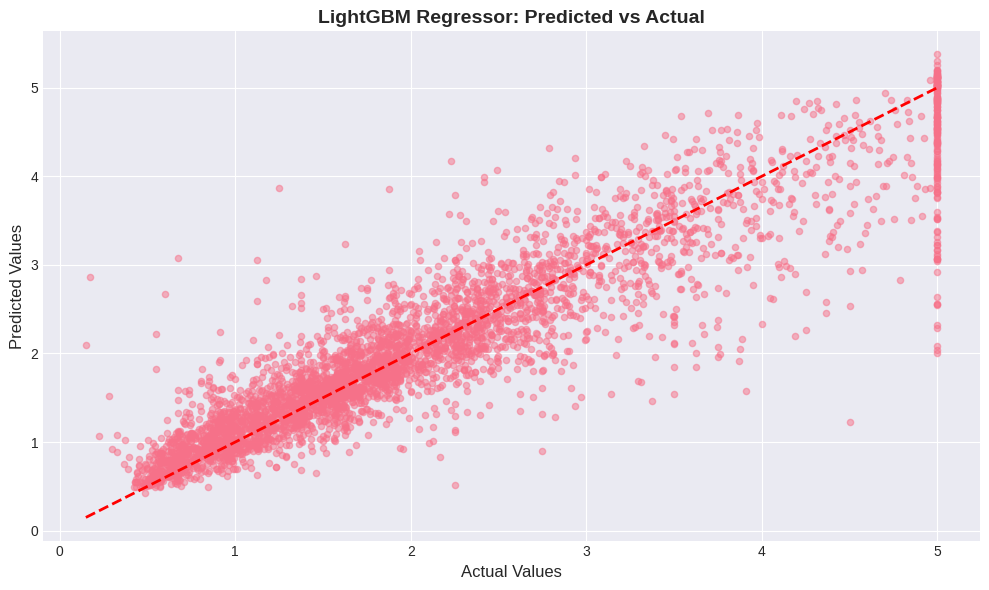

In [3]:
# ⚡ Example 2: LightGBM Regressor
print("=" * 60)
print("📈 LIGHTGBM REGRESSOR EXAMPLE")
print("=" * 60)

# Load California housing dataset
housing = fetch_california_housing()
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing = housing.target

print(f"Dataset shape: {X_housing.shape}")

# Split data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# Initialize and train LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(
    n_estimators=100,
    num_leaves=31,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1
)

lgb_reg.fit(X_train_r, y_train_r)

# Predictions
y_pred_r = lgb_reg.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print(f"\n✅ RMSE: {rmse:.4f}")
print(f"✅ R² Score: {r2:.4f}")

# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.5, s=20)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('LightGBM Regressor: Predicted vs Actual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Important Hyperparameters Deep Dive

### 🎯 Core Parameters:

| Parameter | Description | Default | Typical Range |
|-----------|-------------|---------|---------------|
| `n_estimators` | Number of boosting rounds | 100 | 100-1000 |
| `learning_rate` | Shrinkage factor | 0.1 | 0.01-0.3 |
| `num_leaves` | Max leaves in one tree | 31 | 20-150 |
| `max_depth` | Max tree depth | -1 (no limit) | 5-10 |

### 🛡️ Regularization Parameters:

| Parameter | Description | Default | Purpose |
|-----------|-------------|---------|---------|
| `lambda_l1` | L1 regularization | 0 | Feature selection |
| `lambda_l2` | L2 regularization | 0 | Weight shrinkage |
| `min_data_in_leaf` | Min samples in leaf | 20 | Prevent overfitting |
| `feature_fraction` | Fraction of features per tree | 1.0 | Colsample |
| `bagging_fraction` | Fraction of samples per tree | 1.0 | Subsample |

### 📊 Important Notes:

**num_leaves vs max_depth:**
- `num_leaves` is the primary control for model complexity in LightGBM
- A tree with depth d can have up to 2^d leaves
- Set `num_leaves < 2^max_depth` to avoid overfitting
- Rule of thumb: `num_leaves = 2^max_depth - 1` for balanced trees

**Leaf-wise Growth Consideration:**
- LightGBM grows trees leaf-wise, which can lead to deep trees
- Always set `max_depth` to prevent overfitting
- Use `min_data_in_leaf` to ensure sufficient samples per leaf

In [4]:
# ⚡ Hyperparameter Tuning Example
print("=" * 60)
print("🔧 HYPERPARAMETER TUNING DEMONSTRATION")
print("=" * 60)

# Define parameter grid
param_grid = {
    'num_leaves': [20, 31, 50],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'feature_fraction': [0.8, 1.0],
    'bagging_fraction': [0.8, 1.0]
}

# Use smaller grid for demo
param_grid_demo = {
    'num_leaves': [20, 31],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

lgb_clf_grid = lgb.LGBMClassifier(random_state=42, verbosity=-1)

# Grid Search with 3-fold CV
grid_search = GridSearchCV(
    estimator=lgb_clf_grid,
    param_grid=param_grid_demo,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n🔍 Running Grid Search...")
grid_search.fit(X_train_c, y_train_c)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV Accuracy: {grid_search.best_score_:.4f}")

# Test best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_c)
best_accuracy = accuracy_score(y_test_c, y_pred_best)
print(f"✅ Test Accuracy with Best Params: {best_accuracy:.4f}")

🔧 HYPERPARAMETER TUNING DEMONSTRATION

🔍 Running Grid Search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 20}
✅ Best CV Accuracy: 0.9693
✅ Test Accuracy with Best Params: 0.9649


## 6. Applying LightGBM to Titanic Dataset

Let's apply LightGBM to the Titanic survival prediction problem with proper preprocessing.

In [5]:
# ⚡ Load and Preprocess Titanic Dataset
print("=" * 60)
print("🚢 TITANIC SURVIVAL PREDICTION WITH LIGHTGBM")
print("=" * 60)

# Load Titanic dataset from seaborn
titanic = sns.load_dataset('titanic')

print(f"Original dataset shape: {titanic.shape}")
print(f"\nFirst few rows:")
print(titanic.head())

# Data preprocessing
def preprocess_titanic(df):
    df = df.copy()
    
    # Select relevant features
    features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alone']
    df = df[features + ['survived']].copy()
    
    # Handle missing values
    df['age'].fillna(df['age'].median(), inplace=True)
    df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
    df['fare'].fillna(df['fare'].median(), inplace=True)
    
    # Encode categorical variables
    df['sex'] = df['sex'].map({'male': 0, 'female': 1})
    df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    df['class'] = df['class'].map({'First': 1, 'Second': 2, 'Third': 3})
    df['who'] = df['who'].map({'man': 0, 'woman': 1, 'child': 2})
    df['adult_male'] = df['adult_male'].astype(int)
    df['alone'] = df['alone'].astype(int)
    
    return df

titanic_clean = preprocess_titanic(titanic)
print(f"\n✅ Cleaned dataset shape: {titanic_clean.shape}")
print(f"✅ Missing values: {titanic_clean.isnull().sum().sum()}")

# Prepare features and target
X_titanic = titanic_clean.drop('survived', axis=1)
y_titanic = titanic_clean['survived']

feature_names = X_titanic.columns.tolist()
print(f"\nFeatures: {feature_names}")

# Split data
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic
)

print(f"\nTraining set: {X_train_t.shape}")
print(f"Test set: {X_test_t.shape}")

🚢 TITANIC SURVIVAL PREDICTION WITH LIGHTGBM
Original dataset shape: (891, 15)

First few rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

✅ Cleaned dataset shape: (891, 12)
✅ Missing values: 0

Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embar


🌲 TRAINING LIGHTGBM CLASSIFIER

✅ Test Accuracy: 0.8212
✅ Test AUC: 0.8458

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.80      0.94      0.87       110
    Survived       0.86      0.64      0.73        69

    accuracy                           0.82       179
   macro avg       0.83      0.79      0.80       179
weighted avg       0.83      0.82      0.81       179



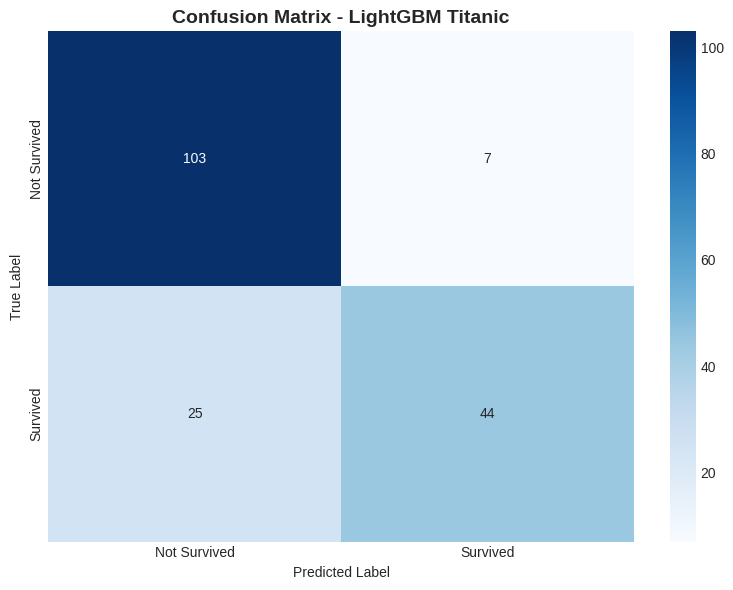

In [6]:
# ⚡ Train LightGBM on Titanic
print("\n" + "=" * 60)
print("🌲 TRAINING LIGHTGBM CLASSIFIER")
print("=" * 60)

# Initialize LightGBM with good default parameters
lgb_titanic = lgb.LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    max_depth=6,
    learning_rate=0.1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    lambda_l1=0.1,
    lambda_l2=0.1,
    min_data_in_leaf=20,
    random_state=42,
    verbosity=-1
)

# Train with evaluation set for early stopping demonstration
lgb_titanic.fit(
    X_train_t, y_train_t,
    eval_set=[(X_test_t, y_test_t)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# Predictions
y_pred_t = lgb_titanic.predict(X_test_t)
y_pred_proba_t = lgb_titanic.predict_proba(X_test_t)[:, 1]

accuracy_t = accuracy_score(y_test_t, y_pred_t)
auc_t = roc_auc_score(y_test_t, y_pred_proba_t)

print(f"\n✅ Test Accuracy: {accuracy_t:.4f}")
print(f"✅ Test AUC: {auc_t:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_t, y_pred_t, target_names=['Not Survived', 'Survived']))

# Confusion Matrix
cm = confusion_matrix(y_test_t, y_pred_t)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - LightGBM Titanic', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 7. Training with Early Stopping and Validation Set

Early stopping is crucial for gradient boosting to prevent overfitting and find the optimal number of iterations.

⏹️ EARLY STOPPING DEMONSTRATION
✅ Optimal number of trees: 34


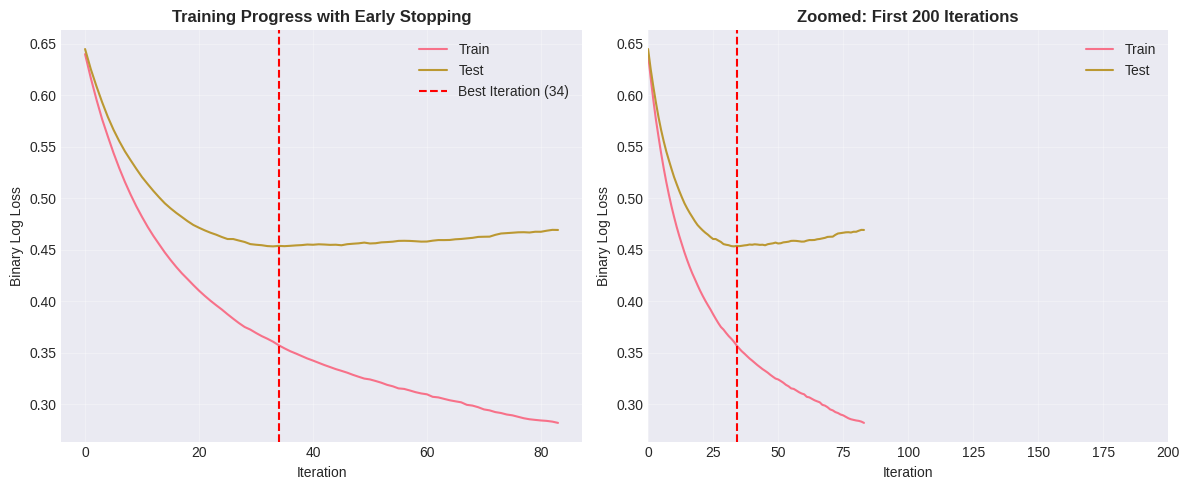

In [7]:
# ⚡ Early Stopping Demonstration
print("=" * 60)
print("⏹️ EARLY STOPPING DEMONSTRATION")
print("=" * 60)

# Train with early stopping
lgb_early = lgb.LGBMClassifier(
    n_estimators=1000,  # Large number, early stopping will find optimal
    num_leaves=31,
    max_depth=6,
    learning_rate=0.05,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    random_state=42,
    verbosity=-1
)

# Train with early stopping and record evaluation results
lgb_early.fit(
    X_train_t, y_train_t,
    eval_set=[(X_train_t, y_train_t), (X_test_t, y_test_t)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.record_evaluation(eval_result={})
    ]
)

print(f"✅ Optimal number of trees: {lgb_early.best_iteration_}")

# Get evaluation results
evals_result = lgb_early.evals_result_

# Plot training progress
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(evals_result['training']['binary_logloss'], label='Train')
plt.plot(evals_result['valid_1']['binary_logloss'], label='Test')
plt.axvline(lgb_early.best_iteration_, color='r', linestyle='--', 
            label=f'Best Iteration ({lgb_early.best_iteration_})')
plt.xlabel('Iteration')
plt.ylabel('Binary Log Loss')
plt.title('Training Progress with Early Stopping', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(evals_result['training']['binary_logloss'], label='Train')
plt.plot(evals_result['valid_1']['binary_logloss'], label='Test')
plt.axvline(lgb_early.best_iteration_, color='r', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Binary Log Loss')
plt.title('Zoomed: First 200 Iterations', fontweight='bold')
plt.xlim(0, 200)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Importance in LightGBM

LightGBM provides multiple ways to interpret feature importance:

1. **split**: Number of times a feature is used in splits
2. **gain**: Total gain of splits using the feature
3. **gain_avg**: Average gain per split

Gain is generally more informative as it considers both frequency and importance of splits.

📊 FEATURE IMPORTANCE ANALYSIS

Feature Importance (sorted by gain):
   feature  split       gain  gain_normalized
       sex      0   0.000000         0.000000
     alone      1   1.204670         0.000678
     sibsp      3   7.321818         0.004121
     parch      5   7.363003         0.004145
  embarked     17  47.783969         0.026897
     class      6  50.176930         0.028244
       age     57  93.896602         0.052854
adult_male      2 140.980297         0.079357
    pclass     19 253.153942         0.142499
      fare    116 339.418922         0.191057
       who     15 835.234909         0.470148


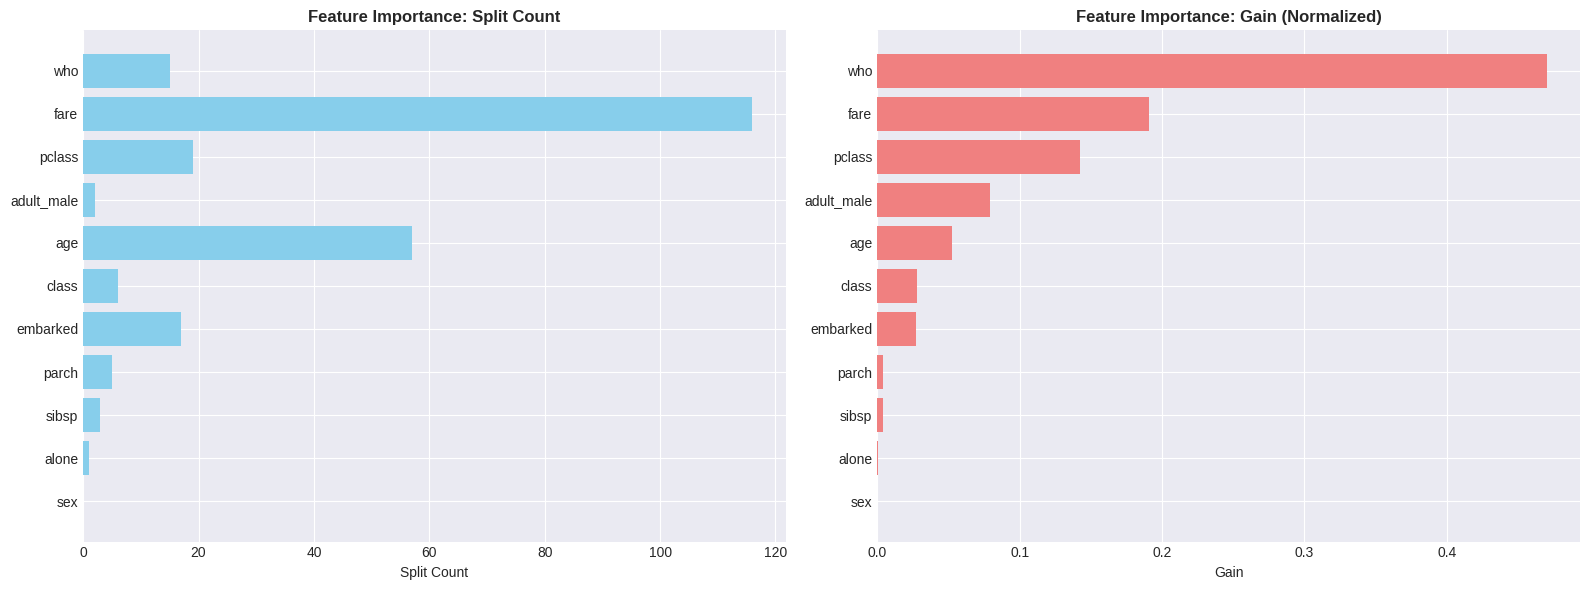


💡 Key Insights:
- 'Gain' shows which features contribute most to reducing loss
- 'Split' shows which features are used most frequently
- High gain features are crucial for model predictions
- Consider removing low gain features for simpler models


In [8]:
# ⚡ Feature Importance Analysis
print("=" * 60)
print("📊 FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Get feature importance
importance_split = lgb_titanic.feature_importances_
importance_gain = lgb_titanic.booster_.feature_importance(importance_type='gain')

# Create DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'split': importance_split,
    'gain': importance_gain
})

importance_df['gain_normalized'] = importance_df['gain'] / importance_df['gain'].sum()
importance_df = importance_df.sort_values('gain', ascending=True)

print("\nFeature Importance (sorted by gain):")
print(importance_df.to_string(index=False))

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(importance_df['feature'], importance_df['split'], color='skyblue')
axes[0].set_title('Feature Importance: Split Count', fontweight='bold')
axes[0].set_xlabel('Split Count')

axes[1].barh(importance_df['feature'], importance_df['gain_normalized'], color='lightcoral')
axes[1].set_title('Feature Importance: Gain (Normalized)', fontweight='bold')
axes[1].set_xlabel('Gain')

plt.tight_layout()
plt.show()

print("\n💡 Key Insights:")
print("- 'Gain' shows which features contribute most to reducing loss")
print("- 'Split' shows which features are used most frequently")
print("- High gain features are crucial for model predictions")
print("- Consider removing low gain features for simpler models")

## 9. Comparison: XGBoost vs LightGBM

Let's compare XGBoost and LightGBM on the same dataset to understand their differences in speed, memory, and accuracy.

In [9]:
import xgboost as xgb
import lightgbm as lgb
import pandas as pd
import time
from sklearn.metrics import accuracy_score, roc_auc_score

# ⚡ XGBoost vs LightGBM Comparison
print("=" * 60)
print("⚔️ XGBOOST vs LIGHTGBM COMPARISON")
print("=" * 60)

# XGBoost
print("\n⚡ Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    # FIXES for categorical data:
    enable_categorical=True,
    tree_method='hist'
)

start_time = time.time()
xgb_model.fit(X_train_t, y_train_t)
xgb_train_time = time.time() - start_time

xgb_pred = xgb_model.predict(X_test_t)
xgb_pred_proba = xgb_model.predict_proba(X_test_t)[:, 1]
xgb_accuracy = accuracy_score(y_test_t, xgb_pred)
xgb_auc = roc_auc_score(y_test_t, xgb_pred_proba)

print(f"✅ XGB Training Time: {xgb_train_time:.3f}s")
print(f"✅ XGB Test Accuracy: {xgb_accuracy:.4f}")
print(f"✅ XGB Test AUC: {xgb_auc:.4f}")

# LightGBM
print("\n🌲 Training LightGBM...")
# Note: LightGBM uses 'feature_fraction' and 'bagging_fraction' instead of colsample/subsample
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    num_leaves=63,
    max_depth=6,
    learning_rate=0.1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,        # Required when using bagging_fraction
    random_state=42,
    verbosity=-1           # Reduce logs
)

start_time = time.time()
# LightGBM automatically detects pandas 'category' columns
lgb_model.fit(X_train_t, y_train_t)
lgb_train_time = time.time() - start_time

lgb_pred = lgb_model.predict(X_test_t)
lgb_pred_proba = lgb_model.predict_proba(X_test_t)[:, 1]
lgb_accuracy = accuracy_score(y_test_t, lgb_pred)
lgb_auc = roc_auc_score(y_test_t, lgb_pred_proba)

print(f"✅ LGB Training Time: {lgb_train_time:.3f}s")
print(f"✅ LGB Test Accuracy: {lgb_accuracy:.4f}")
print(f"✅ LGB Test AUC: {lgb_auc:.4f}")

# Comparison summary
print("\n" + "=" * 60)
print("📊 COMPARISON SUMMARY")
print("=" * 60)
comparison_df = pd.DataFrame({
    'Metric': ['Training Time (s)', 'Test Accuracy', 'Test AUC', 'Speedup Factor'],
    'XGBoost': [f"{xgb_train_time:.4f}", f"{xgb_accuracy:.4f}", f"{xgb_auc:.4f}", 1.0],
    'LightGBM': [f"{lgb_train_time:.4f}", f"{lgb_accuracy:.4f}", f"{lgb_auc:.4f}", f"{xgb_train_time/lgb_train_time:.2f}x"]
})
print(comparison_df.to_string(index=False))

print("\n💡 Key Differences:")
print(f"- Speed: LightGBM is typically {xgb_train_time/lgb_train_time:.1f}x faster on large datasets.")
print("- Strategy: XGBoost grows trees level-wise (balanced), while LightGBM grows leaf-wise (best-first).")
print("- Categoricals: Both support native categories, but LightGBM's implementation is often more memory-efficient.")

⚔️ XGBOOST vs LIGHTGBM COMPARISON

⚡ Training XGBoost...
✅ XGB Training Time: 0.439s
✅ XGB Test Accuracy: 0.8101
✅ XGB Test AUC: 0.8373

🌲 Training LightGBM...
✅ LGB Training Time: 0.101s
✅ LGB Test Accuracy: 0.8156
✅ LGB Test AUC: 0.8327

📊 COMPARISON SUMMARY
           Metric XGBoost LightGBM
Training Time (s)  0.4391   0.1014
    Test Accuracy  0.8101   0.8156
         Test AUC  0.8373   0.8327
   Speedup Factor     1.0    4.33x

💡 Key Differences:
- Speed: LightGBM is typically 4.3x faster on large datasets.
- Strategy: XGBoost grows trees level-wise (balanced), while LightGBM grows leaf-wise (best-first).
- Categoricals: Both support native categories, but LightGBM's implementation is often more memory-efficient.


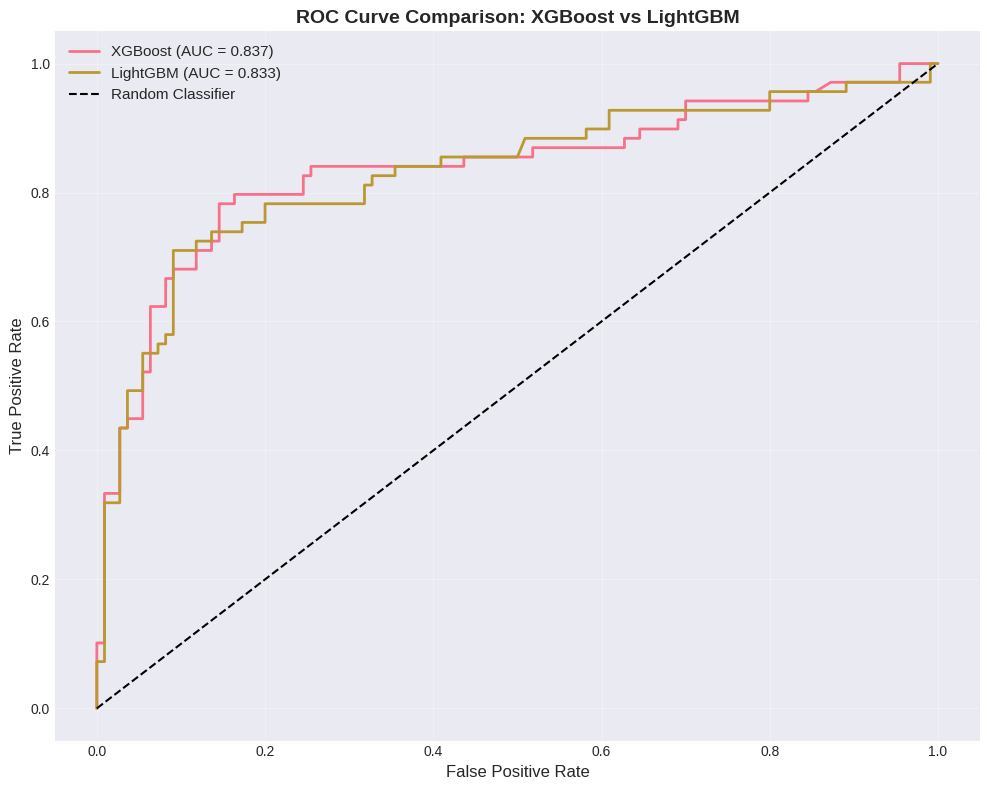

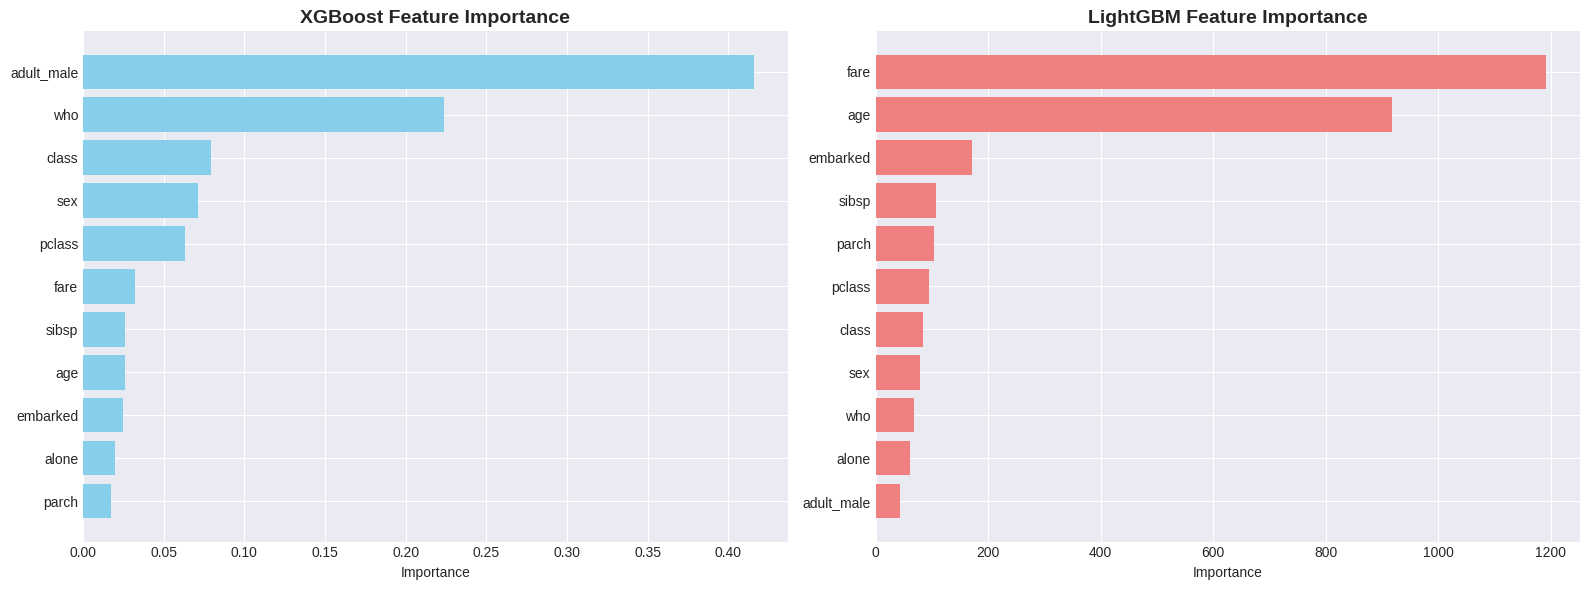

In [10]:
# ⚡ ROC Curve Comparison
plt.figure(figsize=(10, 8))

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_t, xgb_pred_proba)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_auc:.3f})', linewidth=2)

# LightGBM ROC
fpr_lgb, tpr_lgb, _ = roc_curve(y_test_t, lgb_pred_proba)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {lgb_auc:.3f})', linewidth=2)

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: XGBoost vs LightGBM', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost importance
xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(xgb_importance['feature'], xgb_importance['importance'], color='skyblue')
axes[0].set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance')

# LightGBM importance
lgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(lgb_importance['feature'], lgb_importance['importance'], color='lightcoral')
axes[1].set_title('LightGBM Feature Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 10. Best Practices and Tips for Using LightGBM

### 🎯 General Guidelines:

**1. Handling Overfitting:**
```python
# Key parameters to prevent overfitting
max_depth=6  # Limit tree depth
num_leaves=63  # 2^max_depth - 1 for balanced trees
min_data_in_leaf=20  # Ensure sufficient samples per leaf
lambda_l1=0.1  # L1 regularization
lambda_l2=0.1  # L2 regularization
```

**2. Dealing with Imbalanced Data:**
```python
# Use scale_pos_weight for binary classification
scale_pos_weight = len(negative) / len(positive)
is_unbalance=True  # Alternative approach
```

**3. Large Datasets:**
```python
# Use histogram-based optimization
histogram_pool_size=-1  # Use all CPU cores
two_round=True  # For very large datasets
```

**4. Categorical Features:**
```python
# LightGBM can handle categorical features directly!
categorical_feature=['category_col1', 'category_col2']
model.fit(X, y, categorical_feature=categorical_feature)
```

### 🔧 Tuning Strategy:

**Step 1: Start with defaults and tune num_leaves**
```python
num_leaves: 31 (default) → 20-150 depending on data size
max_depth: -1 (no limit) or 6-10
```

**Step 2: Tune learning rate and n_estimators**
```python
learning_rate: 0.1 → 0.01-0.3
n_estimators: Use early stopping to find optimal
```

**Step 3: Add regularization**
```python
feature_fraction: 0.8 (column sampling)
bagging_fraction: 0.8 (row sampling)
bagging_freq: 5 (bagging every 5 iterations)
```

**Step 4: Fine-tune leaf parameters**
```python
min_data_in_leaf: 20-100
lambda_l1: 0-1
lambda_l2: 0-1
```

### ⚡ Performance Optimization:

- Use `n_jobs=-1` for parallel processing
- Enable GPU with `device='gpu'`
- Use `histogram_pool_size` to control memory
- For prediction, use `predict()` with `num_iteration` to use fewer trees

## 🛠️ Hands-On Exercises

Now it's your turn! Complete these exercises to master LightGBM.

### Exercise 1: Basic LightGBM Training
Train a LightGBM classifier on the breast cancer dataset with default parameters and evaluate accuracy.

In [11]:
# Exercise 1: Your code here



### Exercise 2: Implement Early Stopping
Train LightGBM with early stopping on the Titanic dataset and find the optimal number of trees.

In [12]:
# Exercise 2: Your code here



### Exercise 3: Tune num_leaves Parameter
Experiment with different num_leaves values (15, 31, 63, 127) and observe the effect on accuracy and overfitting.

In [13]:
# Exercise 3: Your code here



### Exercise 4: Tune feature_fraction and bagging_fraction
Test different values of feature_fraction and bagging_fraction to find the best combination for regularization.

In [14]:
# Exercise 4: Your code here



### Exercise 5: Compare Training Speed and Accuracy with XGBoost
Compare LightGBM and XGBoost on a larger dataset (California housing) for both speed and accuracy.

In [15]:
# Exercise 5: Your code here



### Exercise 6: Analyze Feature Importance
Analyze and visualize feature importance using both 'split' and 'gain' metrics on the breast cancer dataset.

In [16]:
# Exercise 6: Your code here



### Exercise 7: Build a Complete LightGBM Pipeline with Preprocessing
Create a sklearn Pipeline that includes preprocessing (scaling, encoding) and LightGBM classifier.

In [17]:
# Exercise 7: Your code here



### Exercise 8: Optimize LightGBM for a Regression Task
Tune LightGBM hyperparameters for the California housing dataset to minimize RMSE.

In [18]:
# Exercise 8: Your code here



### Exercise 9: Handle Categorical Features
Use LightGBM's built-in categorical feature support with the Titanic dataset (without one-hot encoding).

In [19]:
# Exercise 9: Your code here



### Exercise 10: Advanced - Custom Evaluation Metric
Implement a custom evaluation metric (e.g., F1-score) using LightGBM's callback system.

In [20]:
# Exercise 10: Your code here (Advanced)



## Solutions (Review After Attempting)

<details>
<summary>Exercise 1 Solution</summary>

```python
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import lightgbm as lgb

# Load data
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train with defaults
model = lgb.LGBMClassifier(random_state=42, verbosity=-1)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
```
</details>

<details>
<summary>Exercise 2 Solution</summary>

```python
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

model.fit(
    X_train_t, y_train_t,
    eval_set=[(X_test_t, y_test_t)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print(f"Best iteration: {model.best_iteration_}")
print(f"Best score: {accuracy_score(y_test_t, model.predict(X_test_t)):.4f}")
```
</details>

<details>
<summary>Exercise 3 Solution</summary>

```python
import matplotlib.pyplot as plt

num_leaves_list = [15, 31, 63, 127]
train_scores = []
test_scores = []

for nl in num_leaves_list:
    model = lgb.LGBMClassifier(num_leaves=nl, max_depth=6, random_state=42, verbosity=-1)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(num_leaves_list, train_scores, label='Train')
plt.plot(num_leaves_list, test_scores, label='Test')
plt.xlabel('num_leaves')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Effect of num_leaves')
plt.show()
```
</details>

<details>
<summary>Exercise 4 Solution</summary>

```python
import pandas as pd
import seaborn as sns

feature_fracs = [0.6, 0.8, 1.0]
bagging_fracs = [0.6, 0.8, 1.0]

results = []
for ff in feature_fracs:
    for bf in bagging_fracs:
        model = lgb.LGBMClassifier(
            feature_fraction=ff,
            bagging_fraction=bf,
            bagging_freq=5,
            random_state=42,
            verbosity=-1
        )
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        results.append({'feature_fraction': ff, 'bagging_fraction': bf, 'accuracy': acc})

results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='feature_fraction', columns='bagging_fraction', values='accuracy')
sns.heatmap(pivot, annot=True, fmt='.4f')
plt.title('Regularization Effects')
plt.show()
```
</details>

<details>
<summary>Exercise 5 Solution</summary>

```python
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import time

housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LightGBM
start = time.time()
lgb_reg = lgb.LGBMRegressor(n_estimators=200, random_state=42, verbosity=-1)
lgb_reg.fit(X_train, y_train)
lgb_time = time.time() - start
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_reg.predict(X_test)))

# XGBoost
start = time.time()
xgb_reg = xgb.XGBRegressor(n_estimators=200, random_state=42)
xgb_reg.fit(X_train, y_train)
xgb_time = time.time() - start
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_reg.predict(X_test)))

print(f"LightGBM: {lgb_time:.3f}s, RMSE: {lgb_rmse:.4f}")
print(f"XGBoost: {xgb_time:.3f}s, RMSE: {xgb_rmse:.4f}")
print(f"Speedup: {xgb_time/lgb_time:.1f}x")
```
</details>

<details>
<summary>Exercise 6 Solution</summary>

```python
model = lgb.LGBMClassifier(random_state=42, verbosity=-1)
model.fit(X_train, y_train)

importance_split = model.feature_importances_
importance_gain = model.booster_.feature_importance(importance_type='gain')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(cancer.feature_names, importance_split)
axes[0].set_title('Split Importance')

axes[1].barh(cancer.feature_names, importance_gain)
axes[1].set_title('Gain Importance')

plt.tight_layout()
plt.show()
```
</details>

<details>
<summary>Exercise 7 Solution</summary>

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', lgb.LGBMClassifier(random_state=42, verbosity=-1))
])

pipeline.fit(X_train, y_train)
print(f"Pipeline Accuracy: {pipeline.score(X_test, y_test):.4f}")
```
</details>

<details>
<summary>Exercise 8 Solution</summary>

```python
from sklearn.model_selection import GridSearchCV

param_grid = {
    'num_leaves': [20, 31, 50],
    'learning_rate': [0.05, 0.1],
    'min_data_in_leaf': [10, 20]
}

grid = GridSearchCV(
    lgb.LGBMRegressor(random_state=42, verbosity=-1),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error'
)

grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best RMSE: {np.sqrt(-grid.best_score_):.4f}")
```
</details>

<details>
<summary>Exercise 9 Solution</summary>

```python
# Load raw titanic with categorical features
titanic = sns.load_dataset('titanic')
titanic['age'].fillna(titanic['age'].median(), inplace=True)

X = titanic[['pclass', 'sex', 'age', 'embarked']].copy()
y = titanic['survived']

# Convert to category dtype
X['pclass'] = X['pclass'].astype('category')
X['sex'] = X['sex'].astype('category')
X['embarked'] = X['embarked'].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = lgb.LGBMClassifier(random_state=42, verbosity=-1)
model.fit(X_train, y_train, categorical_feature=['pclass', 'sex', 'embarked'])

print(f"Accuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")
```
</details>

<details>
<summary>Exercise 10 Solution</summary>

```python
from sklearn.metrics import f1_score

def f1_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    y_pred_binary = (y_pred > 0.5).astype(int)
    return 'f1', f1_score(y_true, y_pred_binary), True

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'None',
    'learning_rate': 0.1,
    'verbose': -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=200,
    valid_sets=[test_data],
    feval=f1_eval,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

y_pred = (model.predict(X_test) > 0.5).astype(int)
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
```
</details>